<a href="https://colab.research.google.com/github/DariaLaska/ml/blob/main/Bag_Of_Words.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация статей

In [ ]:
from google.colab import files # Для работы с файлами
import numpy as np # Для работы с данными
import matplotlib.pyplot as plt # Для вывода графиков
import os # Для работы с файлами
%matplotlib inline

from tensorflow.keras import utils # Для работы с категориальными данными
from tensorflow.keras.models import Sequential # Полносвязная модель
from tensorflow.keras.optimizers import Adam # Оптимизатор
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Activation # Слои для сети
from tensorflow.keras.preprocessing.text import Tokenizer # Методы для работы с текстами
from tensorflow.keras.preprocessing.sequence import pad_sequences # Метод для работы с последовательностями

from google.colab import drive # Для работы с Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Удаляем директорию с распакованными данными (если есть)
!rm -rf /content/books

In [ ]:
!unzip -q '/content/drive/MyDrive/Colab Notebooks/ML/news.zip' -d /content/

In [ ]:
# Функция для загрузки файла
def loadText(fileName):
  f = open(fileName, 'r') # Открываем файл в режиме чтения
  text = f.read()         # Читаем текст

  # Вариант с заменой каждого символа
  #text = text.replace("\n", " ") # Заменяем переносы строк на пробелы
  #text = text.replace("\r", " ") # Заменяем переносы строк на пробелы
  #text = text.replace("\t", " ") # Заменяем табуляции на пробелы

  # Вариант с заменой по словарю
  translation_table = str.maketrans({'\r': ' ', '\n': ' ', '\t': ' '})
  text = text.translate(translation_table)

  f.close()

  return text

labels = ["Культура", "Путешествия", "Наука и техника"] # Наши авторы
labelsNum = len(labels) # Количество авторов

In [ ]:
# Загружаем тексты из обучающей и тренировочной выборок

trainText = [] # Обучающие тексты
testText = []  # Тестовые тексты

fileList = os.listdir('/content/news') # Получаем список всех файлов
print(fileList)
for label in labels:
  for file in fileList:
    if label in file: # Проверяем, содержит ли файл j в названии имя класса i
      if 'Обучающая' in file: # Если в имени найденного класса есть строка "Обучающая"
        trainText.append(loadText('/content/news/' + file)) #добавляем в обучающую выборку
        print(file, 'добавлен в обучающую выборку')
      if 'Тестовая' in file: # Если в имени найденного класса есть строка "Тестовая"
        testText.append(loadText('/content/news/' + file)) #добавляем в обучающую выборку
        print(file, 'добавлен в тестовую выборку')

['(Спорт) Тестовая.txt', '(Путешествия) Обучающая.txt', '(Интернет и СМИ) Тестовая.txt', '(Культура) Тестовая.txt', '(Наука и техника) Тестовая.txt', '(Экономика) Тестовая.txt', '(Наука и техника) Обучающая.txt', '(Экономика) Обучающая.txt', '(Интернет и СМИ) Обучающая.txt', '(Культура) Обучающая.txt', '(Спорт) Обучающая.txt', '(Путешествия) Тестовая.txt']
(Культура) Тестовая.txt добавлен в тестовую выборку
(Культура) Обучающая.txt добавлен в обучающую выборку
(Путешествия) Обучающая.txt добавлен в обучающую выборку
(Путешествия) Тестовая.txt добавлен в тестовую выборку
(Наука и техника) Тестовая.txt добавлен в тестовую выборку
(Наука и техника) Обучающая.txt добавлен в обучающую выборку


In [ ]:
print("Количество загруженных тренировочных текстов:", len(trainText))
print("Количество загруженных тестовых текстов:", len(testText))

Количество загруженных тренировочных текстов: 3
Количество загруженных тестовых текстов: 3


Токенизируем тексты

In [ ]:
numWords = 20_000 # Количество слов/индексов, которое мы будем учитывать при обучении

# Tokenizer - встроенная в Keras функция для разбиения текста и превращения
# в слов в числовые значения с учётом частотности

# num_words - максимальное количество слов/индексов, учитываемое при составлении словаря
# filters - список ненужных символов, которые будут удалены из текстов
# lower - приведение слов к нижнему регистру
# split - разделитель между словами
# oov_token - на какое слово будем заменять слова, которые выше по частоте, чем numWords
# char_level - просим токенайзер не удалять однобуквенные слова

tokenizer = Tokenizer(num_words=numWords,
                      filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                      lower=True,
                      split=' ',
                      oov_token='unknown',
                      char_level=False)

tokenizer.fit_on_texts(trainText) # Cоберем словарь частотности
items = list(tokenizer.word_index.items()) # Получаем индексы слов

In [ ]:
print("Самые часто встречающиеся слова:")
print(items[:14]) # Самые часто встречающиеся слова
print()
print("Самые редко встречающиеся слова:")
print(items[-10:])
print()
print("Размер словаря:", len(items))

Самые часто встречающиеся слова:
[('unknown', 53480), ('в', 2), ('на', 3), ('и', 4), ('что', 5), ('с', 6), ('из', 7), ('по', 8), ('не', 9), ('за', 10), ('для', 11), ('об', 12), ('этом', 13), ('о', 14)]

Самые редко встречающиеся слова:
[('ходаком', 78087), ('географической', 78088), ('атрофией', 78089), ('сетчатку', 78090), ('одновременное', 78091), ('протезного', 78092), ('периферического', 78093), ('франк', 78094), ('хольц', 78095), ('координатором', 78096)]

Размер словаря: 78095


In [ ]:
# Тестирование словаря
inputWord = input("Введите слово: ")
print("Индекс слова ",inputWord, ": ", tokenizer.word_index[inputWord])

Введите слово: лотос
Индекс слова  лотос :  13280


In [ ]:
# Преобразовываем текст в последовательность индексов согласно частотному словарю
trainWordIndexes = tokenizer.texts_to_sequences(trainText)
testWordIndexes = tokenizer.texts_to_sequences(testText)

In [ ]:
# Проверим преобразование
print("Фрагмент обучающего текста:")
print(len(trainText))
print("В виде оригинального текста:              ", trainText[0][:100])
print("Он же в виде последовательности индексов: ", trainWordIndexes[0][:10], '\n')

Фрагмент обучающего текста:
3
В виде оригинального текста:               Глюкоза погасила долг перед налоговой Mash: Глюкоза погасила долг в 263 тысячи рублей перед налогово
Он же в виде последовательности индексов:  [1283, 13226, 2515, 161, 2273, 298, 1283, 13226, 2515, 2] 



In [ ]:
print("Статистика по обучающим текстам:")

symbolsTrainText = 0 # Объявляем переменную для подсчета символов в обучающих текстах
wordsTrainText = 0 # Объявляем переменную для подсчета слов в обучающих текстах

for i in range(labelsNum): # Проходим по всем классам
  print(labels[i], " "*(10-len(labels[i])), len(trainText[i]), "символов, ", len(trainWordIndexes[i]), "слов")
  symbolsTrainText += len(trainText[i]) # Считаем символы
  wordsTrainText += len(trainWordIndexes[i]) # Считаем слова

print('----')
print("В сумме ", symbolsTrainText, " символов, ", wordsTrainText, " слов \n")
print()
print("Статистика по тестовым текстам:")

symbolsTestText = 0 # Объявляем переменную для подсчета символов в тестовых текстах
wordsTestText = 0 # Объявляем переменную для подсчета слов в тестовых текстах

for i in range(labelsNum): #Проходим по всем классам
  print(labels[i], ' '*(10-len(labels[i])), len(testText[i]), "символов, ", len(testWordIndexes[i]), "слов")
  symbolsTestText += len(testText[i]) #Считаем символы
  wordsTestText += len(testWordIndexes[i]) #Считаем слова
print('----')
print("В сумме ", symbolsTestText, " символов, ", wordsTestText, " слов")

Статистика по обучающим текстам:
Культура    2070848 символов,  293519 слов
Путешествия  2347950 символов,  335877 слов
Наука и техника  2604261 символов,  345922 слов
----
В сумме  7023059  символов,  975318  слов 


Статистика по тестовым текстам:
Культура    536105 символов,  76319 слов
Путешествия  537338 символов,  76742 слов
Наука и техника  541044 символов,  71827 слов
----
В сумме  1614487  символов,  224888  слов


Создаем xTrain и yTrain

In [ ]:
# Формирование обучающей выборки по листу индексов слов
# путем разделения на короткие векторы
# wordIndexes - массив индексов
# xLen - размер окна
# step - шаг окна
def getSetFromIndexes(wordIndexes, xLen, step):
  xText = []
  wordsLen = len(wordIndexes) # Считаем количество слов
  index = 0 # Задаем начальный индекс

  while (index + xLen <= wordsLen): # Идём по всей длине вектора индексов
    xText.append(wordIndexes[index:index+xLen]) # "Откусываем" векторы длины xLen
    index += step # Смещаеммся вперёд на step

  return xText


# Формирование обучающей и проверочной выборки для каждого класса
# wordIndexes - массив индексов
# xLen - размер окна
# step - шаг окна
def createSetsMultiClasses(wordIndexes, xLen, step): # Функция принимает последовательность индексов, размер окна, шаг окна
  nClasses = len(wordIndexes) # Количество классов
  classesXSamples = []        # Здесь будет список размером "кол-во классов*кол-во окон в тексте*длину окна (например, 6 по 1341*1000)"
  for wI in wordIndexes:      # Для каждого текста выборки из последовательности индексов
    classesXSamples.append(getSetFromIndexes(wI, xLen, step))

  # Формируем один общий xSamples
  xSamples = []
  ySamples = []

  for t in range(nClasses):
    xT = classesXSamples[t]
    for i in range(len(xT)): # Перебираем каждое окно определенного класса
      xSamples.append(xT[i]) # Добавляем в общий список выборки
      ySamples.append(utils.to_categorical(t, nClasses)) # Добавляем соответствующий вектор класса

  xSamples = np.array(xSamples)
  ySamples = np.array(ySamples)


  return (xSamples, ySamples)

In [ ]:
# Задаём базовые параметры
xLen = 500 # Размер окна (количество слов в векторе)
step = 60 # Шаг разбиения текста на векторы

In [ ]:
# Формируем обучающую и тестовую выборку
xTrainId, yTrain = createSetsMultiClasses(trainWordIndexes, xLen, step)
xTestId, yTest = createSetsMultiClasses(testWordIndexes, xLen, xLen)
print("Размерности тренировочного набора")
print(xTrainId.shape)
print(yTrain.shape)
print()
print("Размерности тестового набора")
print(xTestId.shape)
print(yTest.shape)

Размерности тренировочного набора
(16232, 500)
(16232, 3)

Размерности тестового набора
(448, 500)
(448, 3)


In [ ]:
print(xTrainId[0])

In [ ]:
# Преобразовываем массив векторов в Bag of Words
xTrain = tokenizer.sequences_to_matrix(xTrainId.tolist())
xTest  = tokenizer.sequences_to_matrix(xTestId.tolist())

print("Размерность обучайющей выборки")
print(xTrain.shape)
print(xTrain[0][0:100]) # Фрагмент набора слов в виде Bag of Words
print(xTrain[0][-100:]) # Фрагмент набора слов в виде Bag of Words

print()

print("Размерность тестовой выборки")
print(xTest.shape)
print(xTest[0][0:100]) # Фрагмент набора слов в виде Bag of Words
print(xTest[0][-100:]) # Фрагмент набора слов в виде Bag of Words


Размерность обучайющей выборки
(16232, 20000)
[0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1.
 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]

Размерность тестовой выборки
(448, 20000)
[0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0.
 0. 0. 

Нейросеть для классификации текстов на базе Bag Of Words

In [ ]:
# Создаём полносвязную сеть
model = Sequential()
model.add(Dense(256, input_dim=numWords, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     5,120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121,027 (19.54 MB)

 Trainable params: 5,121,027 (19.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Обучаем сеть
history = model.fit(xTrain,
                    yTrain,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9457 - loss: 0.2185 - val_accuracy: 0.9997 - val_loss: 0.0123
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9997 - val_loss: 0.0067
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 5.6337e-04 - val_accuracy: 0.9997 - val_loss: 0.0045
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 2.8138e-04 - val_accuracy: 0.9997 - val_loss: 0.0035
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 1.7109e-04 - val_accuracy: 0.9997 - val_loss: 0.0029
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 1.1206e-04 - val_accuracy: 0.9997 - val_loss: 0.0026
Epoch 7/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 7.5759e-05 - val_accuracy: 0.9997 - val_loss: 0.0022
Epoch 8/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 5.52

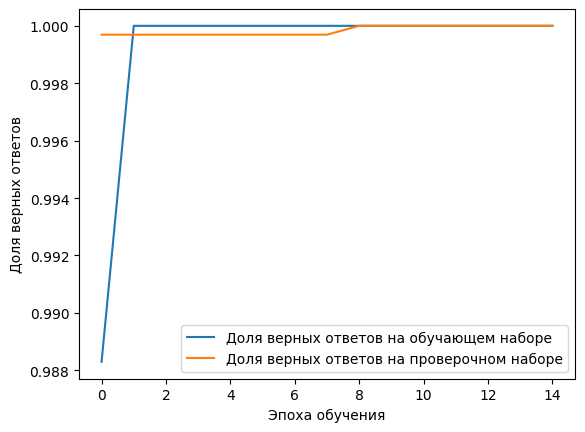

In [ ]:
# Результаты обучения
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

Проверяем работу обученной нейросети

In [ ]:
# Проверяем точность на тестовой выборке

rightAnswer = [0,0,0]
totalAnswer = [0,0,0]

# Получаем результаты распознавания для каждого класса
currPred = model.predict(xTest)
# Определяем номер распознанного класса для каждохо вектора
currOut = np.argmax(currPred, axis=1)
# Определяем правильный класс для каждохо вектора
yOut = np.argmax(yTest, axis=1)

print(currPred.shape)
print(currOut.shape)
print(yOut.shape)
print()


# Считаем сколько ответов всего и сколько из них правильных
for i in range(len(yOut)):
  predictA = currOut[i]
  rightA   = yOut[i]

  totalAnswer[rightA] += 1
  if predictA == rightA:
    rightAnswer[rightA] += 1

# Подсчитываем точность классификации
print("Точность распознавания текстов писателей")
for i in range(labelsNum):
  print("{:12s}: {:3d} из {:3d} - {:3.2f}%".format(labels[i], rightAnswer[i], totalAnswer[i], (rightAnswer[i]/totalAnswer[i]*100)))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
(448, 3)
(448,)
(448,)

Точность распознавания текстов писателей
Культура    : 152 из 152 - 100.00%
Путешествия : 153 из 153 - 100.00%
Наука и техника: 143 из 143 - 100.00%


# Проверка на тексте пользователя

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
my_text = input("Введите text: ")

# Вариант с заменой по словарю
translation_table = str.maketrans({'\r': ' ', '\n': ' ', '\t': ' '})
my_text_list =[]
my_text_list.append(my_text.translate(translation_table))
print(len(my_text_list[0]))

mytestWordIndexes = tokenizer.texts_to_sequences(my_text_list)
padded = pad_sequences(mytestWordIndexes, maxlen=xLen, padding='post')
print(mytestWordIndexes)
myxTestId, myyTest = createSetsMultiClasses(padded, xLen, 100)
print(myxTestId)
print(myyTest)
myxTest  = tokenizer.sequences_to_matrix(myxTestId.tolist())

print(myxTest)

# Проверяем точность на тестовой выборке

Введите text: Гумилев отправляется в путь из Петербурга 7 сентября, через Киев добирается в Одессу, где садится на пароход «Россия» того же РОПиТ. Тогда суда еженедельно ходили по маршруту Одесса — Константинополь — Смирна — Пирей — Александрия. В Синопе он проводит четыре дня в карантине, а затем прибывает в Константинополь. Возможно, изначально у поэта был билет только до Константинополя, потому что Гумилев задержался в этом городе на несколько дней и продолжил свой путь уже на другом пароходе. Он высаживается в Пирее и Афинах, посещает Акрополь, 1 октября прибывает в Александрию и едет в Каир.
589
[[53480, 53480, 2, 1561, 7, 986, 198, 87, 119, 3968, 53480, 2, 53480, 165, 53480, 3, 53480, 490, 62, 114, 53480, 406, 1129, 53480, 10730, 8, 3207, 53480, 53480, 53480, 53480, 53480, 2, 53480, 16, 2372, 418, 578, 2, 53480, 24, 398, 53480, 2, 53480, 1537, 1382, 21, 11350, 48, 2131, 107, 27, 53480, 488, 5, 53480, 12812, 2, 13, 439, 3, 137, 354, 4, 2715, 512, 1561, 86, 3, 791, 53480, 16, 53480

In [ ]:
# Формирование обучающей выборки по листу индексов слов
# путем разделения на короткие векторы
# wordIndexes - массив индексов
# xLen - размер окна
# step - шаг окна
def getSetFromIndexes(wordIndexes, xLen, step):
  xText = []
  wordsLen = len(wordIndexes) # Считаем количество слов
  print(f'amount of w: {wordsLen}')
  index = 0 # Задаем начальный индекс

  while (index + xLen <= wordsLen): # Идём по всей длине вектора индексов
    xText.append(wordIndexes[index:index+xLen]) # "Откусываем" векторы длины xLen
    print(wordIndexes[index:index+xLen])
    index += step # Смещаеммся вперёд на step

  return xText


# Формирование обучающей и проверочной выборки для каждого класса
# wordIndexes - массив индексов
# xLen - размер окна
# step - шаг окна
def createSetsMultiClasses(wordIndexes, xLen, step): # Функция принимает последовательность индексов, размер окна, шаг окна
  nClasses = len(wordIndexes) # Количество классов
  classesXSamples = []        # Здесь будет список размером "кол-во классов*кол-во окон в тексте*длину окна (например, 6 по 1341*1000)"
  for wI in wordIndexes:      # Для каждого текста выборки из последовательности индексов
    classesXSamples.append(getSetFromIndexes(wI, xLen, step))
    print(f'small func: {classesXSamples}')

  # Формируем один общий xSamples
  xSamples = []
  ySamples = []

  for t in range(nClasses):
    xT = classesXSamples[t]
    for i in range(len(xT)): # Перебираем каждое окно определенного класса
      xSamples.append(xT[i]) # Добавляем в общий список выборки
      ySamples.append(utils.to_categorical(t, nClasses)) # Добавляем соответствующий вектор класса

  xSamples = np.array(xSamples)
  ySamples = np.array(ySamples)


  return (xSamples, ySamples)

In [ ]:
rightAnswer = [0,0,0]
totalAnswer = [0,0,0]

# Получаем результаты распознавания для каждого класса
print(myxTest.shape)
Pred = model.predict(myxTest)

print(Pred)

labels = ["Культура", "Путешествия", "Наука и техника"]
print(labels)

currOut = np.argmax(Pred, axis=1)
print(labels[int(currOut)])

(1, 20000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.19939739 0.6803905  0.12021216]]
['Культура', 'Путешествия', 'Наука и техника']
Путешествия


/tmp/ipython-input-1673513927.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(labels[int(currOut)])


Карл Павлович Брюллов (при рождении и до 1822 года — Брюлло) — русский живописец и рисовальщик из семьи Брюлловых, последователь романтизма. Мастер исторической картины и монументальных росписей, также успешно работал как портретист и жанрист
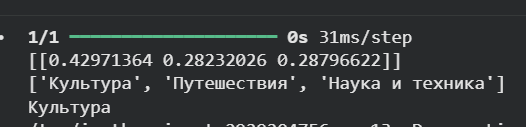

Гумилев отправляется в путь из Петербурга 7 сентября, через Киев добирается в Одессу, где садится на пароход «Россия» того же РОПиТ. Тогда суда еженедельно ходили по маршруту Одесса — Константинополь — Смирна — Пирей — Александрия. В Синопе он проводит четыре дня в карантине, а затем прибывает в Константинополь. Возможно, изначально у поэта был билет только до Константинополя, потому что Гумилев задержался в этом городе на несколько дней и продолжил свой путь уже на другом пароходе. Он высаживается в Пирее и Афинах, посещает Акрополь, 1 октября прибывает в Александрию и едет в Каир.

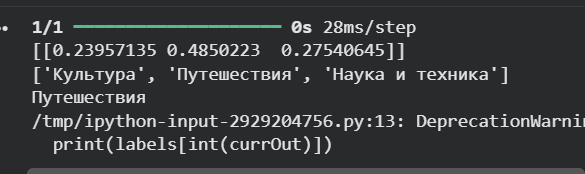

Область параметров вимпов ограничена фоном от упругого когерентного рассеяния солнечных и атмосферных нейтрино, которое может давать сигналы, схожие с ожидаемыми от частиц темной материи в области малых сечений взаимодействия этих частиц с веществом детекторов. Чтобы продолжить поиск, исследователям необходимо зафиксировать и охарактеризовать этот фон
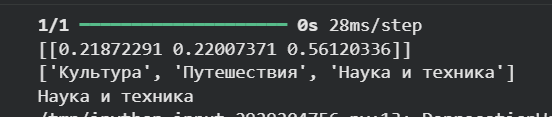